# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [1]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

! pip install numpy
! pip install pandas
! pip install seaborn
! pip install matplotlib
! pip install pillow
! pip install tensorflow
! pip install keras
! pip install  tensorflow.keras.models


ERROR: Could not find a version that satisfies the requirement tensorflow.keras.models (from versions: none)
ERROR: No matching distribution found for tensorflow.keras.models


In [2]:
# Import essential libraries
from google.colab import drive
import os
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive


drive.mount('/content/drive')


Mounted at /content/drive


Load the dataset.

In [3]:
import zipfile

# Assuming the dataset zip file is named 'dataset.zip' and located in /content/drive/My Drive/colab Notebooks/
dataset_zip_path = '/content/drive/My Drive/Colab Notebooks/Dataset_Waste_Segregation/data.zip' # Update this path if your zip file is elsewhere or named differently

# Check if the zip file exists before attempting to unzip
if os.path.exists(dataset_zip_path):
    # Unzip the dataset
    with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print(f"Successfully unzipped {dataset_zip_path} to /content/")

    # List the contents of the extracted directory to verify
    # This assumes the zip extracts into a subfolder or directly into /content/
    # Adjust path if needed, e.g., os.listdir('/content/extracted_folder_name')
    print("Contents after extraction:")
    print(os.listdir('/content/'))
else:
    print(f"Error: The dataset zip file was not found at {dataset_zip_path}. Please ensure it's uploaded or downloaded correctly.")


Successfully unzipped /content/drive/My Drive/Colab Notebooks/Dataset_Waste_Segregation/data.zip to /content/
Contents after extraction:
['.config', 'data', 'drive', 'sample_data']


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [4]:
# Create a function to load the raw images
def load_images(directory):
    images = []
    for path in os.listdir(directory):
        img = Image.open(os.path.join(directory, path))
        images.append(img)
    return images



#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [5]:
# Get the images and their labels
from pathlib import Path
images = []
labels = []
image_dirs=[]

data_dir = Path('/content/data')

for d in data_dir.iterdir():
    if d.is_dir():
        print(f'Found class directory: {d.name}')
        image_dirs.append(d)

for subdir in image_dirs:
    label = str(subdir).split("/")[-1]
    print(label)
    # Correctly append images and labels by iterating through each directory
    current_dir_images = load_images(str(subdir))
    images.extend(current_dir_images)
    labels.extend([label] * len(current_dir_images))

print(f'Number of images: {len(images)}')
print(f'Number of labels: {len(labels)}')


Found class directory: Glass
Found class directory: Paper
Found class directory: Other
Found class directory: Plastic
Found class directory: Food_Waste
Found class directory: Metal
Found class directory: Cardboard
Glass
Paper
Other
Plastic
Food_Waste
Metal
Cardboard
Number of images: 7625
Number of labels: 7625


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

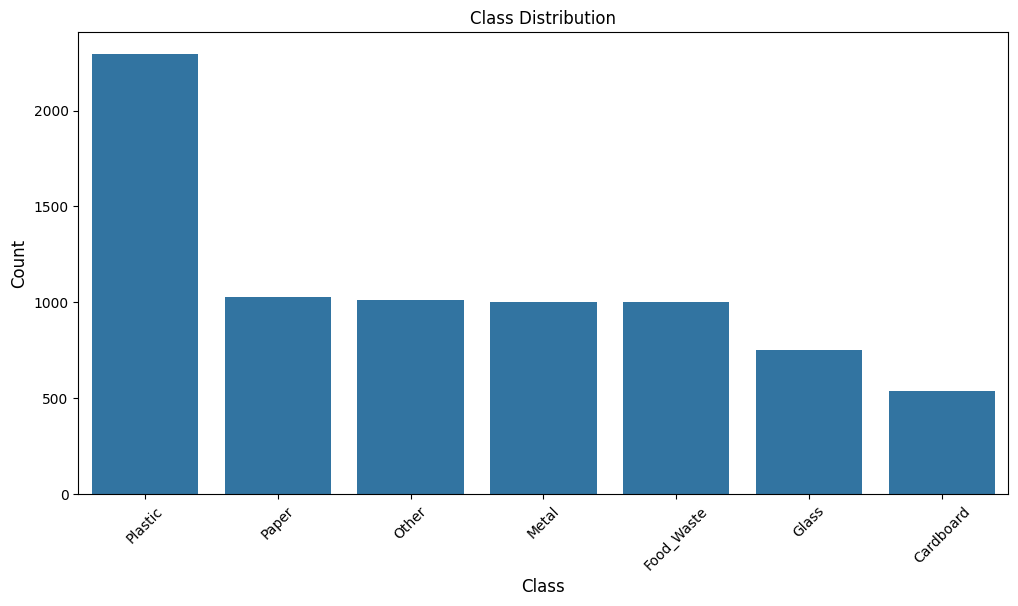

In [6]:
# Visualise Data Distribution
label_counts = pd.Series(labels).value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Class Distribution')
plt.ylabel('Count', fontsize=12)
plt.xlabel('Class', fontsize=12)
plt.xticks(rotation=45)
plt.show()



#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

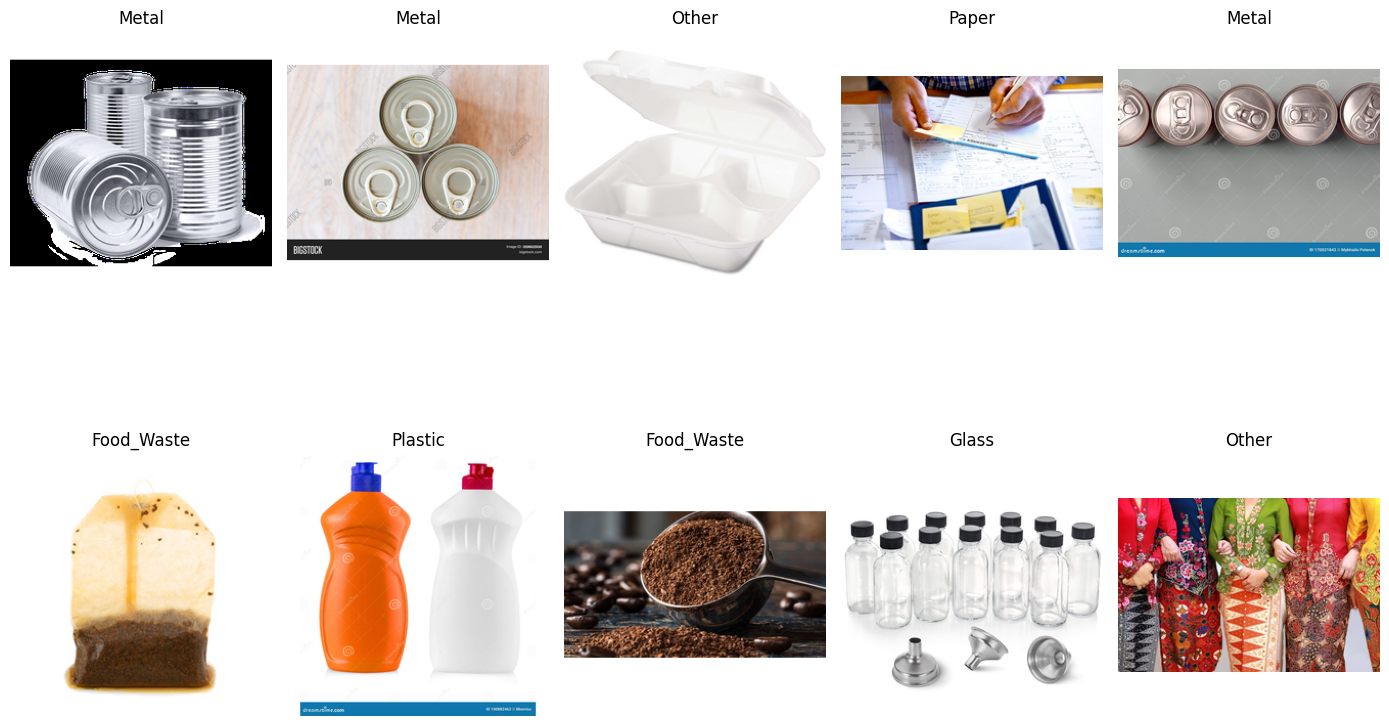

In [7]:
# Visualise Sample Images (across different labels)
num_samples = 10
sample_idx = np.random.choice(len(images), size=num_samples, replace=False)

rows, cols = 2, 5
fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
for i, idx in enumerate(sample_idx):
    row, col = divmod(i, cols)
    ax = axes[row, col]
    ax.imshow(images[idx])
    ax.set_title(labels[idx])
    ax.axis('off')
plt.tight_layout()
plt.show()




#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [8]:
# Find the smallest and largest image dimensions from the data set
min_width = min(img.width for img in images)
min_height = min(img.height for img in images)

print(f"Smallest width: {min_width}")
print(f"Smallest height: {min_height}")



Smallest width: 256
Smallest height: 256


In [9]:
# Resize the image dimensions
target_size = (128, 128)
resized_images = [img.resize(target_size) for img in images]




### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [10]:
# Encode the labels suitably
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)


print(encoded_labels[:10])

for i, label in enumerate(label_encoder.classes_):
  print(f"{label} → {i}")



[2 2 2 2 2 2 2 2 2 2]
Cardboard → 0
Food_Waste → 1
Glass → 2
Metal → 3
Other → 4
Paper → 5
Plastic → 6


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [11]:
# Assign specified parts of the dataset to train and validation sets
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    resized_images,
    encoded_labels,
    test_size=0.2,
    random_state=42,
    stratify=encoded_labels
)

print('Training set size:', len(X_train))
print('Validation set size:', len(X_val))




Training set size: 6100
Validation set size: 1525


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [12]:
# Build and compile the model using 3 convolutional layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D


# Get the number of classes from the label_encoder (defined in an earlier cell)
num_classes = len(label_encoder.classes_)

# Build the model
model = Sequential([
    # 1st Convolutional Block. #Edge Detections
    Conv2D(
        32, # 32 features detectors
        (3, 3), # each filter 3x3
        activation='relu',
        input_shape=(128, 128, 3) #height=128, width=128, channel=RGB
        ),
    MaxPooling2D(pool_size=(2, 2)), # reduce spatial dimensions while retaining the most important features.

    # 2nd Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # 3rd Convolutional Block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten + Dense Layers
    Flatten(),# Converts 2D feature maps → 1D vector
    Dense(128, activation='relu'),


    Dropout(0.5), #Randomly disables 50% of neurons during training this is reqgularization for overfitting
    # Changed for multi-class classification: output layer has 'num_classes' neurons and 'softmax' activation
    Dense(num_classes, activation='softmax') #Produces probabilities for each class
])

# Compile the model
model.compile(
    optimizer='adam',
    # Changed for multi-class classification: use 'sparse_categorical_crossentropy' loss
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [13]:
# Train the model
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Convert lists of PIL Images to NumPy arrays
X_train_array = np.array([np.array(img) for img in X_train])
X_val_array = np.array([np.array(img) for img in X_val])

# Normalize pixel values to be between 0 and 1
X_train_array = X_train_array.astype('float32') / 255.0
X_val_array = X_val_array.astype('float32') / 255.0

# Define EarlyStopping callback
#The EarlyStopping callback monitors the validation loss (val_loss) during training and will stop if it doesn't improve for 5 consecutive epochs (patience=5). It then restores the model to the weights from the best-performing epoch (restore_best_weights=True) to prevent overfitting.
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model using the already defined and compiled model object
history = model.fit(
    X_train_array,
    y_train, # Use integer-encoded labels
    epochs=20, # You can adjust the number of epochs
    batch_size=32,
    validation_data=(X_val_array, y_val), # Use integer-encoded labels
    callbacks=[early_stopping]
)


Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.3134 - loss: 1.7858 - val_accuracy: 0.3692 - val_loss: 1.6505
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.3862 - loss: 1.6154 - val_accuracy: 0.4203 - val_loss: 1.5101
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4154 - loss: 1.5255 - val_accuracy: 0.4459 - val_loss: 1.4436
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4530 - loss: 1.4324 - val_accuracy: 0.4852 - val_loss: 1.3705
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.4985 - loss: 1.3344 - val_accuracy: 0.4944 - val_loss: 1.3881
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5523 - loss: 1.2087 - val_accuracy: 0.5148 - val_loss: 1.2946
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5990 - loss: 1.0812 - val_accuracy: 0.5541 - val_loss: 1.2535
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6428 - loss: 0.9590 - val_acc

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on the validation dataset. Derive appropriate metrics.

In [14]:
# Evaluate on the validation set; display suitable metrics
from sklearn.metrics import classification_report

# Evaluate the model on the validation set
loss, accuracy = model.evaluate(X_val_array, y_val)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Make predictions on the validation set
y_pred_probs = model.predict(X_val_array)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate a classification report
# Use the label_encoder from previous cells to get class names
class_names = label_encoder.classes_
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=class_names))

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5823 - loss: 1.2122
Validation Loss: 1.2122
Validation Accuracy: 0.5823
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

Classification Report:
              precision    recall  f1-score   support

   Cardboard       0.67      0.67      0.67       108
  Food_Waste       0.67      0.64      0.65       200
       Glass       0.57      0.48      0.52       150
       Metal       0.54      0.54      0.54       200
       Other       0.53      0.42      0.47       202
       Paper       0.62      0.36      0.45       206
     Plastic       0.56      0.77      0.65       459

    accuracy                           0.58      1525
   macro avg       0.59      0.55      0.56      1525
weighted avg       0.59      0.58      0.57      1525



## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [ ]:
# Define augmentation steps to augment images





Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [ ]:
# Create a function to augment the images




In [ ]:
# Create the augmented training dataset



##### **4.1.2**

Train the model on the new augmented dataset.

In [ ]:
# Train the model using augmented images



## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results

# Data Insights

### Dataset Summary

The dataset contains **7,625 images** distributed across seven waste categories: *Cardboard, Food Waste, Glass, Metal, Other, Paper,* and *Plastic*.

### Class Distribution

The dataset is **imbalanced**. *Plastic* is the most represented class with **2,295 images**, while *Cardboard* has the fewest at **540 images**. This imbalance is likely to affect model performance,particularly for underrepresented classes.

### Image Characteristics

All images have a minimum resolution of **256×256 pixels**. For training purposes, they were resized to **128×128 pixels**.

### Data Preparation

-   Images were loaded and resized
-   Labels were encoded using `LabelEncoder`
-   The dataset was split into **80% training** and **20% validation** sets
-   Stratified sampling was applied to preserve class distribution across splits

------------------------------------------------------------------------

# Model Training Summary

### Architecture

A Convolutional Neural Network (CNN) was implemented with: - Three
convolutional layers with ReLU activation, each followed by max-pooling\
- A Flatten layer
- A Dense layer
- A Dropout layer (0.5) for regularization
- A final Dense layer with **softmax activation** for multi-class classification

------------------------------------------------------------------------

### Training Configuration

-   Optimizer: Adam
-   Loss function: sparse categorical crossentropy
-   Batch size: 32
-   Epochs: up to 20
-   Early stopping: patience of 5 epochs, based on validation loss

------------------------------------------------------------------------

# Model Performance

### Validation Metrics

-   Validation accuracy: **58.23%**
-   Validation loss: **1.2122**

------------------------------------------------------------------------

# Classification Report Analysis

-   *Plastic* achieved high recall (**0.77**)
-   Its large representation in the dataset contributes significantly to overall accuracy
-   *Cardboard*, *Food Waste*, and *Metal* show relatively balanced precision and recall (approximately **0.54--0.67**)
-   *Glass*, *Other*, and *Paper* exhibit lower performance
-   *Paper* in particular has low recall (**0.36**), indicating many missed predictions

This reduced performance is likely influenced by: - class imbalance and visual similarity between certain categories

------------------------------------------------------------------------

# Overall Assessment

The model demonstrates reasonable baseline performance but struggles with certain classes. The imbalance in class distribution appears to be
a significant contributing factor.

------------------------------------------------------------------------

# Recommended Next Step

As suggested in the optional section, applying **data augmentation** would likely improve: - generalization
- performance on minority classes
- robustness of feature learning

------------------------------------------------------------------------

#  Summary

The model performs adequately overall but is biased toward dominant classes. Addressing class imbalance and improving data diversity will increase the  performance gains.
